Same as with the control, but between different perturbation pairs rather than between a perturbation and a control. This is because when looking at the control, we didn't see many perturbations that caused a divergence in cell subtypes, which is the most natural test for scLEMBAS. In this way, we can always define a divergent direction (the perturbation with the larger relative distance between subtypes). 

In [4]:
import os
import sys
import warnings
import copy
from contextlib import contextmanager
from collections import defaultdict
import joblib
import itertools
import warnings

from tqdm import trange, tqdm

import numpy as np
import pandas as pd
import scanpy as sc

from scipy.spatial.distance import mahalanobis, cosine
from scipy import stats
from sklearn.decomposition import PCA

import matplotlib.colors as mcolors

import umap


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.')
from notebook_utils import clear_adata, get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls


In [5]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [6]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [7]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}
        
def run_pls_(tf_adata_sub, n_components = None):
    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_sub, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'both', 
            pert_col = pert_col, 
            cat_col = 'secretory_mcc_subsets', 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    pls_model = models['pls_model']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant'

    # formatting
    tf_adata_sub.obsm['X_pls'] = X_pls
    X_pls = pd.DataFrame(
        X_pls, index = tf_adata_sub.obs_names, columns = ['PLS{}'.format(i+1) for i in range(X_pls.shape[1])]
    )
    for col in [cat_col, 'secretory_mcc_subsets', pert_col]:
        X_pls[col] = tf_adata_sub.obs[col].copy()
        
    return pls_model, X_pls
        
    
def get_mahanalobis_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # pooled covariance
    S = np.cov(np.vstack([g1.values, g2.values]).T)
    S_inv = np.linalg.inv(S)

    # Mahalanobis distance
    m_distance = mahalanobis(m1, m2, S_inv)
    
    return m_distance

def get_euclidean_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # Euclidean distance
    e_distance = np.linalg.norm(m1 - m2)
    
    return e_distance

def get_pert_vector(X, origin_pert):
    pls_cols = X.columns.drop(pert_col)
    ctrl_centroid = X[X[pert_col] == origin_pert][pls_cols].mean().values
    pert_centroid = X[X[pert_col] != origin_pert][pls_cols].mean().values
    return pert_centroid - ctrl_centroid

def get_projection(vector_a, vector_control):
    """
    Project vector_a onto vector_control and return the scalar coefficient
    of the projection along with the magnitude of the orthogonal error.

    Parameters
    ----------
    vector_a : array-like
        Input vector to be projected (e.g., perturbation vector).
    vector_control : array-like
        Reference vector onto which vector_a is projected (e.g., control/global direction).
    error_frac : float
        Fraction of the total magnitude of vector_a that lies orthogonal to vector_control,
        defined as ||vector_a - projection|| / ||vector_a||.

        This represents the proportion of vector_a that is not explained by the control
        direction (i.e., the perturbation-specific component). Values range from 0 to 1:
            - 0 indicates full alignment with vector_control (no unique component)
            - 1 indicates complete orthogonality (entirely unique component)

    Notes
    -----
    - The projection is computed as:
          proj = (a · c) / (c · c) * c
    - The residual (error) is:
          error = a - proj
    - This decomposition separates vector_a into:
          (i) component aligned with vector_control (shared/global effect)
          (ii) orthogonal component (specific/unique effect)
    - The normalized error (error_frac) provides a scale-invariant measure of the
      unique component, enabling comparison across vectors of different magnitudes.
      Unnormalized residual: the raw size of that unique part. A subtype that shifts a lot will tend to have a bigger residual just because everything about its response is bigger.
      Normalized residual: the unique part divided by the total shift size. So you're asking "of all the shifting this subtype did, what fraction went in a unique direction?"
      euclidean/mahanalobis distance already accounts for the strong subtype shifts
    """

    a = np.asarray(vector_a)
    c = np.asarray(vector_control)

    coef = np.dot(a, c) / np.dot(c, c)
    
    proj = coef * c
    error = a - proj
    error_mag = np.linalg.norm(error)
    
    # normalize to vector being projected -- what fraction of the shift is unique?
    # Unnormalized residual: the raw size of that unique part. A subtype that shifts a lot will tend to have a bigger residual just because everything about its response is bigger.
    # Normalized residual: the unique part divided by the total shift size. So you're asking "of all the shifting this subtype did, what fraction went in a unique direction?"
    # euclidean/mahanalobis distance already accounts for the strong subtype shifts
    
    error_frac = error_mag / np.linalg.norm(vector_a) 

    return coef, error_frac


In [8]:
has_subtype = ['Club', 'Goblet', 'Multiciliated']

ct_pert_map = {}
for ct in tf_adata.obs[cat_col].cat.categories:
    if ct not in has_subtype:
        continue
    ct_pert_map[ct] = sorted(tf_adata.obs[tf_adata.obs[cat_col] == ct][pert_col].unique())
    ct_pert_map[ct].remove(ctrl_pert)

In this instance, we only proceed with instances in which both the Euclidean adn Mahanalobis distance agree regarding directionality (both consistently say one pertrubation subtype distance is relatively less than the other). The pertrubation that has the smaller separation by subtype is the one we treat as the origin (as the control in the subtype_response_control script); this ensures that the other perturbation is inducing a "divergence" in cell state between cell subtypes. 

In [9]:
run_umap = False

pls_models, pls_dataframes, umap_dataframes = {}, {}, {}
distances_df = []#defaultdict(list)

for ct, perts in ct_pert_map.items():
    for (pert1, pert2) in tqdm(itertools.combinations(perts, r = 2)):
        
        ct_mask = tf_adata.obs[cat_col] == ct
        pert_mask = tf_adata.obs[pert_col].isin([pert1, pert2])
        
        tf_adata_sub = tf_adata[ct_mask & pert_mask].copy()
        
        pert1_mask = (tf_adata_sub.obs[pert_col] == pert1)
        a = tf_adata_sub[pert1_mask].obs.secretory_mcc_subsets.nunique() == 1
        b = tf_adata_sub[~pert1_mask].obs.secretory_mcc_subsets.nunique() == 1
        if a or b:
            continue
        assert tf_adata_sub.obs.secretory_mcc_subsets.nunique() == 2, 'Incorrect no. of cell type subsets'
        assert tf_adata_sub.obs[cat_col].nunique() == 1, 'Incorrect no. of cell types'
        tf_adata_sub = clear_adata(tf_adata_sub)
        
        # pls
        pls_model, X_pls = run_pls_(tf_adata_sub, n_components = None)
        q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
        if q2y_pval > 0.05:
            continue
        
        # DISTANCE METRICS
        pert1_mask = (X_pls[pert_col] == pert1)
        X_pert1 = X_pls[pert1_mask].drop(columns = [cat_col, pert_col]).copy()
        X_pert2 = X_pls[~pert1_mask].drop(columns = [cat_col, pert_col]).copy()

        e_pert1_distance = get_euclidean_distance(X = X_pert1)
        e_pert2_distance = get_euclidean_distance(X = X_pert2)

        m_pert1_distance = get_mahanalobis_distance(X = X_pert1)
        m_pert2_distance = get_mahanalobis_distance(X = X_pert2)

        e_pert_ratio = e_pert2_distance/e_pert1_distance
        m_pert_ratio = m_pert2_distance/m_pert1_distance
        
        ######################## Set an "origin" perturbation that has smaller separation ########################
        concordant = (e_pert_ratio > 1 and m_pert_ratio > 1) or \
                     (e_pert_ratio < 1 and m_pert_ratio < 1)
        if not concordant:
            continue
        if e_pert_ratio > 1:
            origin_pert = pert1
            divergent_pert = pert2
            
            e_origin_distance = e_pert1_distance
            e_divergent_distance = e_pert2_distance
            
            m_origin_distance = m_pert1_distance
            m_divergent_distance = m_pert2_distance
            
        else:
            origin_pert = pert2
            divergent_pert = pert1
            
            e_origin_distance = e_pert2_distance
            e_divergent_distance = e_pert1_distance
            
            m_origin_distance = m_pert2_distance
            m_divergent_distance = m_pert1_distance
            
            e_pert_ratio = 1/e_pert_ratio
            m_pert_ratio = 1/m_pert_ratio
            
        cond = ct + '^' + '->'.join([origin_pert, divergent_pert])
        pls_models[cond] = pls_model
        pls_dataframes[cond] = X_pls
        ##########################################################################################################

        
        # ANGULAR METRICS
        subtype_labels = X_pls['secretory_mcc_subsets'].unique()
        subtype_labels = sorted(subtype_labels, key=lambda x: 'transition' not in x) # transition is first
        subtype_mask = (X_pls.secretory_mcc_subsets == subtype_labels[0])
        X_transitional_subtype = X_pls[subtype_mask].drop(columns = [cat_col, 'secretory_mcc_subsets']).copy()
        X_mature_subtype = X_pls[~subtype_mask].drop(columns = [cat_col, 'secretory_mcc_subsets']).copy()

        # vectors between perturbation and control for each subtype
        transition_vector = get_pert_vector(X = X_transitional_subtype, origin_pert = origin_pert)
        mature_vector = get_pert_vector(X = X_mature_subtype, origin_pert = origin_pert)
        parent_vector = get_pert_vector(X = X_pls.drop(columns = [cat_col, 'secretory_mcc_subsets']).copy(), origin_pert = origin_pert) # not subtype specific


        subtype_cosine = cosine(transition_vector, mature_vector)
        transition_projection_coef, transition_projection_error = get_projection(transition_vector, parent_vector)
        mature_projection_coef, mature_projection_error = get_projection(mature_vector, parent_vector)

        # store
        metrics = {
            'euclidean_origin_distance': e_origin_distance,
            'euclidean_divergent_distance': e_divergent_distance,
            'euclidean_distance_ratio': e_pert_ratio, 

            'mahanalobis_origin_distance': m_origin_distance,
            'mahanalobis_divergent_distance': m_divergent_distance,
            'mahanalobis_distance_ratio': m_pert_ratio, 
            
            'subtype_cosine_distance': subtype_cosine, 
            
            'transition_projection_coef': transition_projection_coef, 
            'transition_projection_error': transition_projection_error, 
            'mature_projection_coef': mature_projection_coef, 
            'mature_projection_error': mature_projection_error, 
            
            'cell_type': ct, 
            'origin_perturbation': origin_pert, 
            'divergent_perturbation': divergent_pert,
            'condition': cond
            
        }
        distances_df.append(metrics)
        
        if run_umap:
            md_cols = [cat_col, pert_col, 'secretory_mcc_subsets']

            umap_model = umap.UMAP(
                n_neighbors=15,
                n_components=2,
                metric='euclidean',
                #target_metric='categorical',
                n_jobs = n_cores,
                random_state = seed)

            X_pls_values = X_pls.drop(columns = md_cols).values
            if X_pls.shape[1] == 2:
                X_umap = X_pls_values
            else:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message=".*n_jobs value 1 overridden to 1 by setting random_state.*", category=UserWarning)
                    umap_model.fit(X_pls_values) #, adata_sub.obs[separate_col].cat.codes.values)
                X_umap = umap_model.transform(X_pls_values)
            X_umap = pd.DataFrame(X_umap, index = X_pls.index.copy(), columns = ['UMAP{}'.format(i + 1) for i in range(2)])
            X_umap[md_cols] = X_pls[md_cols]
            umap_dataframes[cond] = X_umap

distances_df = pd.DataFrame(distances_df)

10it [01:44, 10.50s/it]
1it [00:01,  1.31s/it]
6it [01:05, 10.96s/it]


In [10]:
pca_cols = [
    'euclidean_distance_ratio',      # keeps euclidean, ratio is most meaningful
    'mahanalobis_distance_ratio',    # keeps mahalanobis, ratio is most meaningful
    'subtype_cosine_distance',       # direction-based, independent
    'transition_projection_error',   # normalized residual (once you normalize it)
    'mature_projection_error',       # normalized residual (once you normalize it)
]

distances_df[pca_cols].corr(method = 'spearman')

,euclidean_distance_ratio,mahanalobis_distance_ratio,subtype_cosine_distance,transition_projection_error,mature_projection_error
euclidean_distance_ratio,1.000000,0.221429,0.646429,0.046429,0.192857
mahanalobis_distance_ratio,0.221429,1.000000,0.196429,0.750000,0.385714
subtype_cosine_distance,0.646429,0.196429,1.000000,0.267857,0.428571
transition_projection_error,0.046429,0.750000,0.267857,1.000000,0.078571
mature_projection_error,0.192857,0.385714,0.428571,0.078571,1.000000


Given that there are many distance metrics, let's summarize them with PCA:

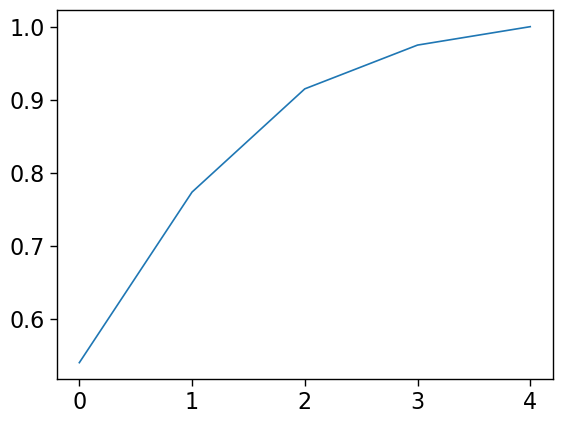

In [11]:
X = distances_df[pca_cols].values

# standardize
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# fit PCA
pca_full = PCA()
pca_full.fit(X_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))

# 2 components is justified
pca = PCA(n_components=2)   # 2 if including projection errors
X_pca = pca.fit_transform(X_scaled)

# add back to dataframe
distances_df[['PC1', 'PC2']] = X_pca

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
)
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index)[['PC1']])
print(loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index)[['PC2']])

                                  PC1
transition_projection_error  0.519418
subtype_cosine_distance      0.515844
mahanalobis_distance_ratio   0.489065
mature_projection_error      0.381582
euclidean_distance_ratio     0.281639
                                  PC2
euclidean_distance_ratio     0.759803
mahanalobis_distance_ratio  -0.434711
transition_projection_error -0.372915
subtype_cosine_distance      0.282289
mature_projection_error      0.122367


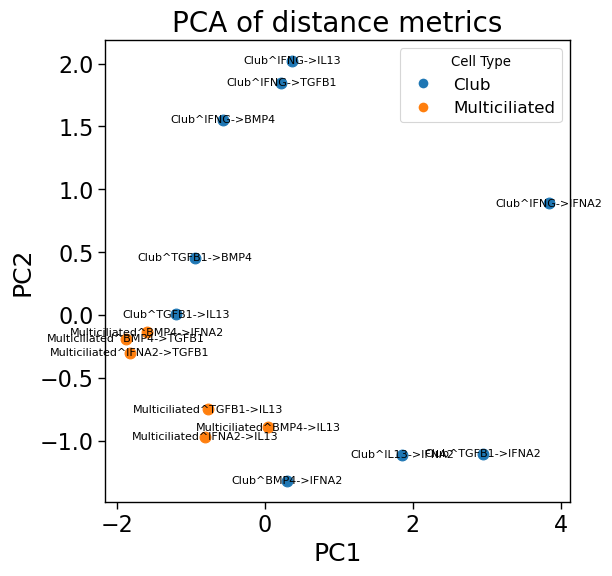

In [11]:

fig, ax = plt.subplots(figsize=(6, 6))

# unique categories
cell_types = distances_df['cell_type'].unique()

# color map
colors = plt.cm.tab10(range(len(cell_types)))
color_map = dict(zip(cell_types, colors))

# plot
for _, row in distances_df.iterrows():
    ax.scatter(
        row['PC1'], row['PC2'],
        color=color_map[row['cell_type']],
        s=60
    )
    ax.text(row['PC1'], row['PC2'], row['condition'],
            fontsize=8, ha='center', va='center')

# axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of distance metrics')

# cell type legend (colors only)
handles_ct = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[ct], markersize=8, label=ct)
    for ct in cell_types
]

ax.legend(handles=handles_ct, title='Cell Type', loc='upper right')

plt.show()

In [13]:
var_explained = pca.explained_variance_ratio_  
distances_df['pc_magnitude_weighted'] = np.sqrt(
    (distances_df['PC1'] * var_explained[0])**2 + 
    (distances_df['PC2'] * var_explained[1])**2
)
distances_df.sort_values('pc_magnitude_weighted', ascending=False, inplace = True)
distances_df.reset_index(inplace = True, drop = True)
distances_df[['condition'] + pca_cols]

,condition,euclidean_distance_ratio,mahanalobis_distance_ratio,subtype_cosine_distance,transition_projection_error,mature_projection_error
0,Club^IFNG->IFNA2,2.789874,2.225772,0.288133,0.809532,0.288314
1,Club^TGFB1->IFNA2,1.532297,2.677249,0.186851,0.690787,0.356040
2,Club^IL13->IFNA2,1.427768,2.087888,0.061057,0.722715,0.507311
3,Multiciliated^BMP4->TGFB1,1.292092,1.295556,0.009657,0.141314,0.010969
4,Multiciliated^IFNA2->TGFB1,1.050907,1.062348,0.030830,0.228781,0.028882
5,Multiciliated^BMP4->IFNA2,1.257333,1.153464,0.035607,0.235430,0.030693
6,Club^TGFB1->IL13,1.202123,1.300689,0.020984,0.116954,0.294440
7,Club^TGFB1->BMP4,1.171402,1.060848,0.089497,0.118611,0.304640
8,Club^IFNG->IL13,2.395385,1.272825,0.139123,0.081066,0.438409
9,Multiciliated^IFNA2->IL13,1.086264,1.807836,0.030523,0.277067,0.085639


Condition: Club^BMP4->IFNA2 | 5 components | Q2Y 0.794 (p = 9.90E-03)
Condition: Club^IFNG->BMP4 | 3 components | Q2Y 0.496 (p = 9.90E-03)
Condition: Club^TGFB1->BMP4 | 5 components | Q2Y 0.494 (p = 9.90E-03)
Condition: Club^IFNG->IFNA2 | 5 components | Q2Y 0.701 (p = 9.90E-03)
Condition: Club^IL13->IFNA2 | 4 components | Q2Y 0.858 (p = 9.90E-03)
Condition: Club^TGFB1->IFNA2 | 4 components | Q2Y 0.749 (p = 9.90E-03)
Condition: Club^IFNG->IL13 | 3 components | Q2Y 0.550 (p = 9.90E-03)
Condition: Club^IFNG->TGFB1 | 2 components | Q2Y 0.619 (p = 9.90E-03)
Condition: Club^TGFB1->IL13 | 3 components | Q2Y 0.589 (p = 9.90E-03)
Condition: Multiciliated^BMP4->IFNA2 | 6 components | Q2Y 0.738 (p = 9.90E-03)
Condition: Multiciliated^BMP4->IL13 | 6 components | Q2Y 0.711 (p = 9.90E-03)
Condition: Multiciliated^BMP4->TGFB1 | 5 components | Q2Y 0.232 (p = 9.90E-03)
Condition: Multiciliated^IFNA2->IL13 | 10 components | Q2Y 0.821 (p = 9.90E-03)
Condition: Multiciliated^IFNA2->TGFB1 | 5 components | 

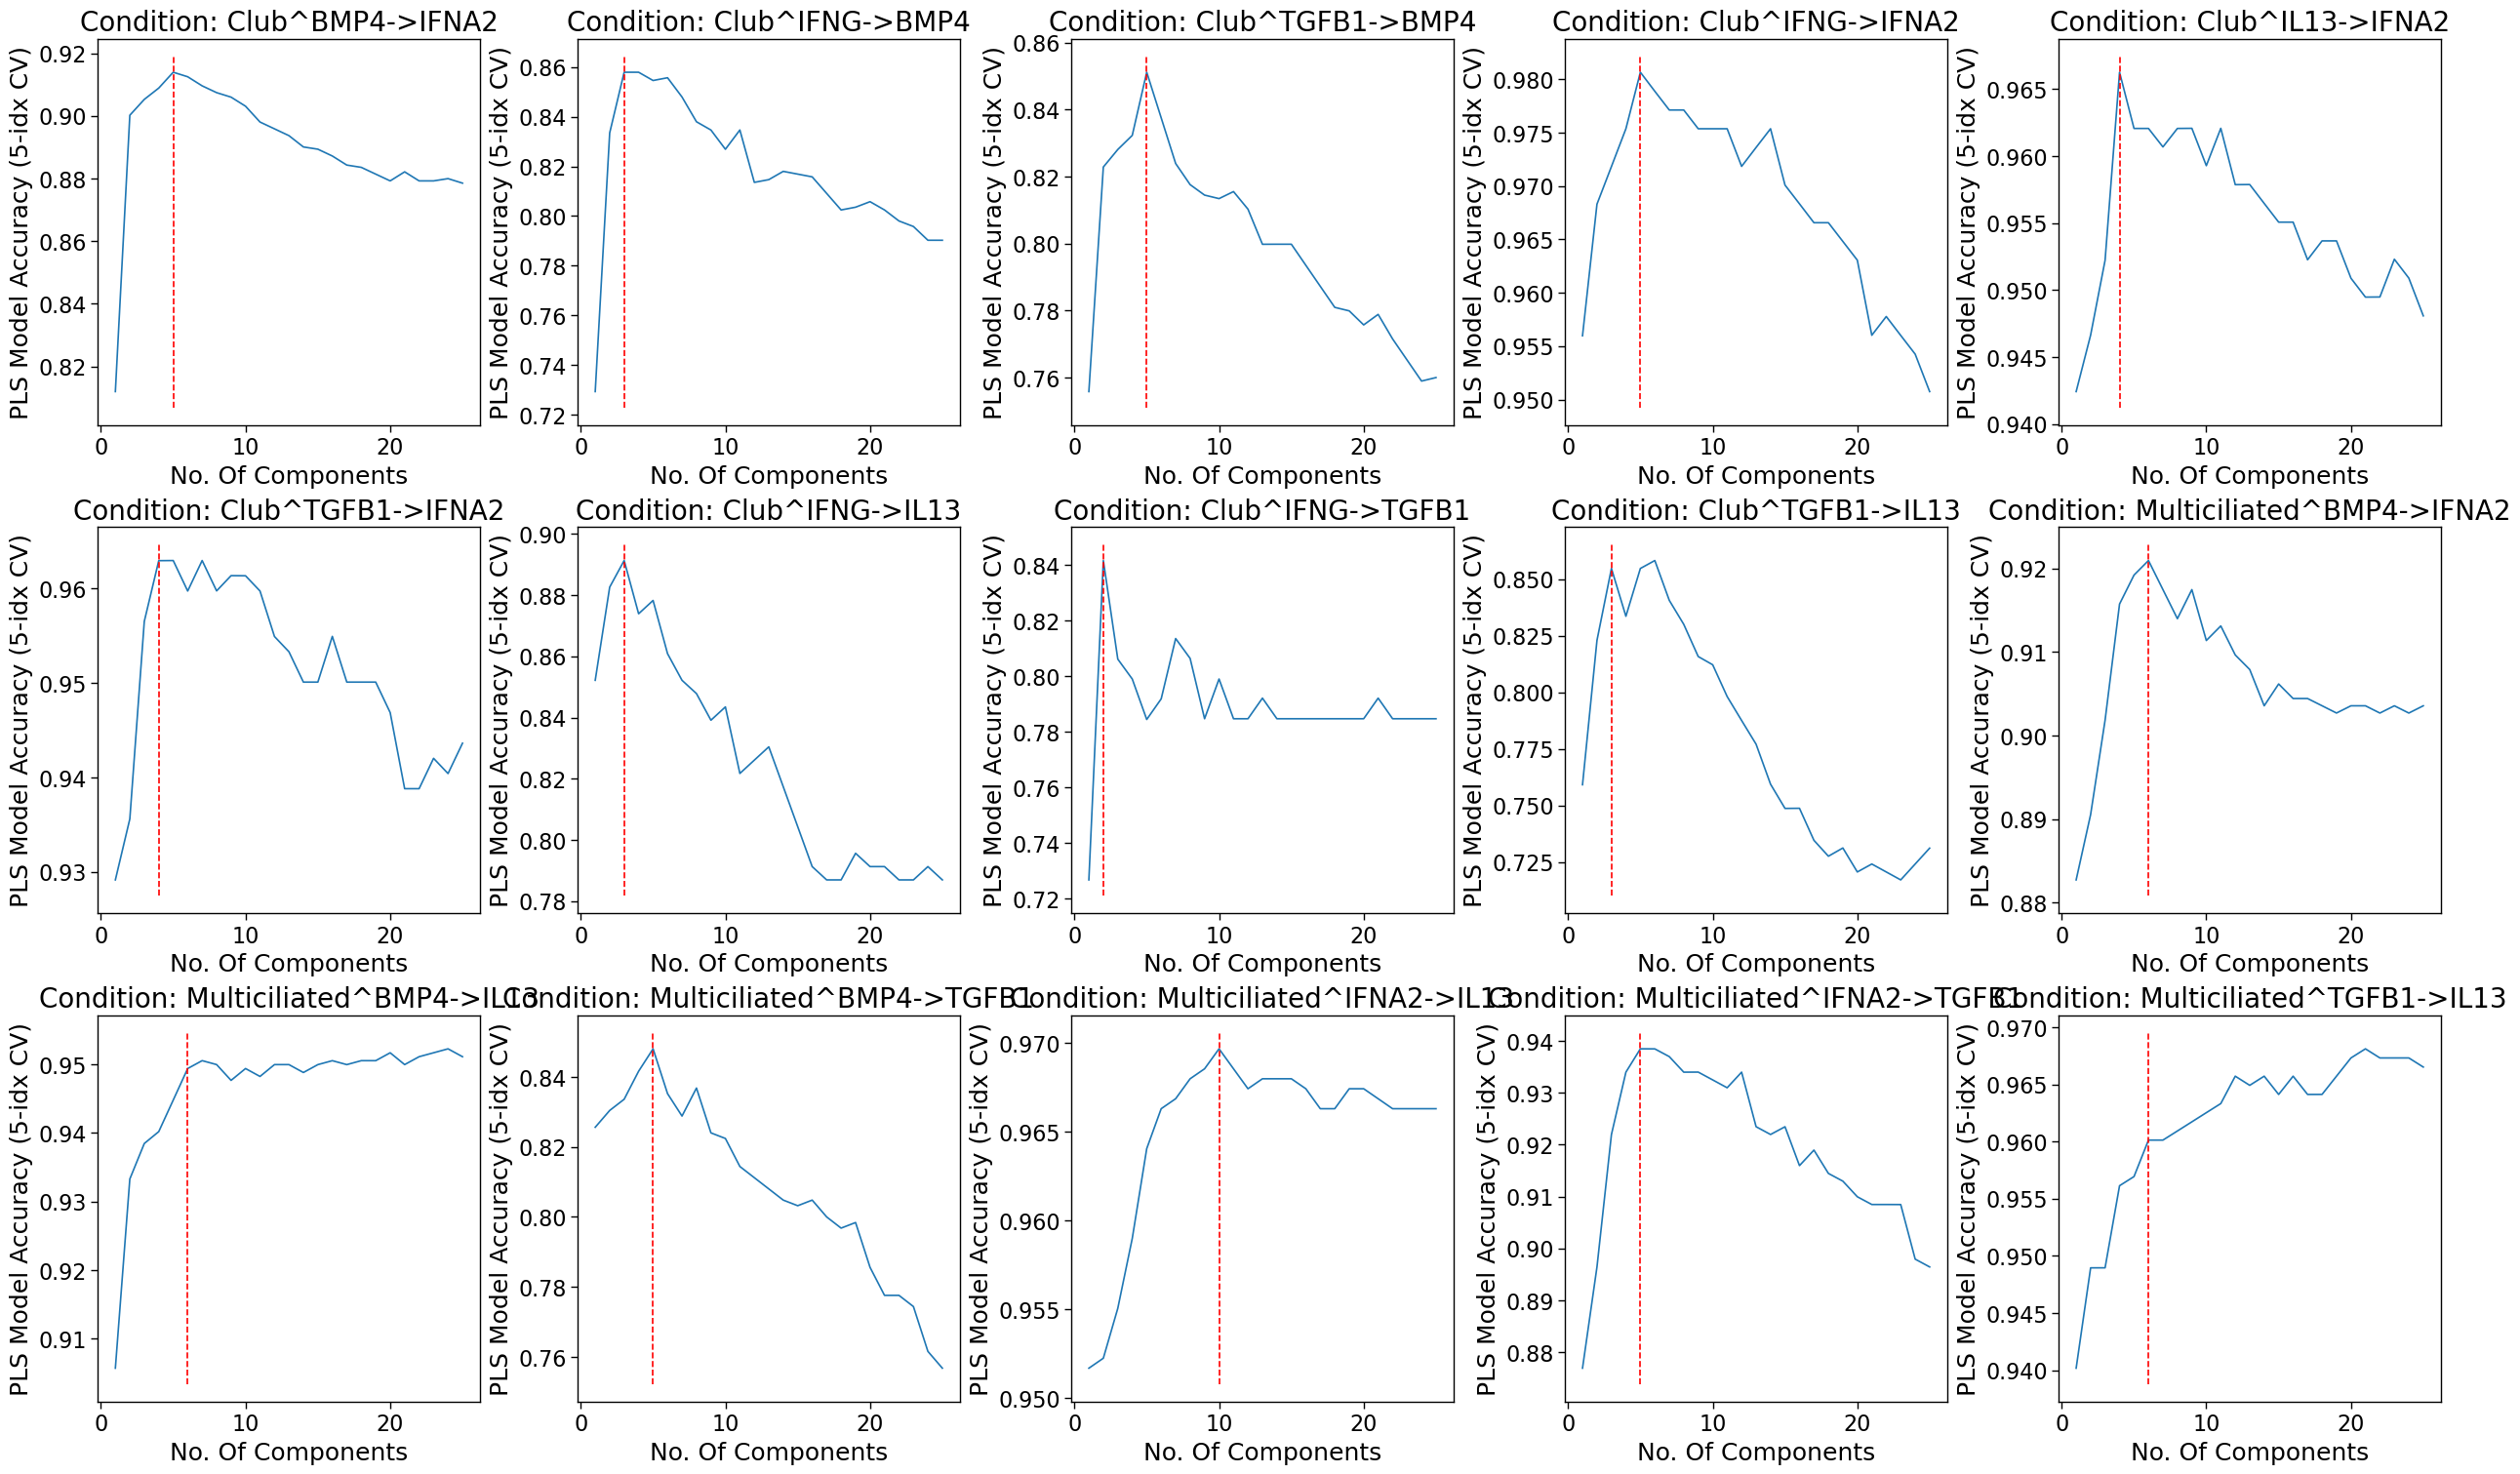

In [13]:
n_panels = len(pls_models) - 1
ncols = min(5, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (5*ncols, 5*nrows), constrained_layout = True)
ax = np.array(ax).reshape(-1)

for idx, (cond, pls_model) in enumerate(pls_models.items()):
    
    ax[idx].set_xlabel('No. Of Components')
    ax[idx].set_ylabel('PLS Model Accuracy (5-idx CV)')
    ax[idx].set_title('Condition: {}'.format(cond))
    
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Condition: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(cond, n_components, q2y, q2y_pval))
    
    if cond == 'Club^IFNA2':
        continue
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[idx])
    ymin, ymax = ax[idx].get_ylim()
    ax[idx].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    
for j in range(idx + 1, len(ax)):
    ax[j].axis('off')
    

Based on the plots above, we will modify the 'Club^IFNA2' condition to contain 12 components rather than 1. 

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np

def plot_panel(viz_df, ax, cond_, n_scatter, origin_pert):

    pls_cols = [c for c in viz_df.columns if c not in ['secretory_mcc_subsets', pert_col]]
    x_col, y_col = pls_cols[:2]

    viz_df_ = viz_df.copy()

    viz_df_['subtype_plot'] = np.where(
        viz_df_['secretory_mcc_subsets'].str.contains('transitional', case=False, na=False),
        'Transitional',
        'Mature'
    )

    viz_df_['pert_plot'] = np.where(
        viz_df_[pert_col] == origin_pert,
        'Origin',
        'Divergent'
    )

    cond_order = [
        'Transitional | Origin',
        'Mature | Origin',
        'Transitional | Divergent',
        'Mature | Divergent'
    ]

    subtype_palette = {
        'Transitional': '#66c2ff',
        'Mature': '#f4a261'
    }

    pert_linestyle = {
        'Origin': 'solid',
        'Divergent': 'dashed'
    }

    pert_marker = {
        'Origin': 'o',
        'Divergent': '^'
    }

    for cond in cond_order:
        subtype, pert_status = cond.split(' | ')
        sub_df = viz_df_[
            (viz_df_['subtype_plot'] == subtype) &
            (viz_df_['pert_plot'] == pert_status)
        ]

        if sub_df.shape[0] > n_scatter:
            sns.kdeplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                fill=False,
                levels=5,
                color=subtype_palette[subtype],
                linestyles=pert_linestyle[pert_status]
            )
        else:
            sns.scatterplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                color=subtype_palette[subtype],
                marker=pert_marker[pert_status],
                s=40
            )

    legend_handles = [
        Patch(facecolor=subtype_palette['Transitional'], label='Transitional'),
        Patch(facecolor=subtype_palette['Mature'], label='Mature'),
        Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Origin'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Divergent'),
        Line2D([0], [0], marker='o', linestyle='', color='black', label='Origin (scatter)'),
        Line2D([0], [0], marker='^', linestyle='', color='black', label='Divergent (scatter)')
    ]

    ax.legend(handles=legend_handles, title='Subtype / Condition', ncol=3)
    ax.set_title(': '.join(cond_.split('^')))

In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np


def darken_color(color, factor=0.65):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))


def plot_panel(viz_df, ax, cond_, n_scatter, origin_pert, display_vectors=True):

    pls_cols = [c for c in viz_df.columns if c not in ['secretory_mcc_subsets', pert_col]]
    x_col, y_col = pls_cols[:2]

    viz_df_ = viz_df.copy()

    viz_df_['subtype_plot'] = np.where(
        viz_df_['secretory_mcc_subsets'].str.contains('transitional', case=False, na=False),
        'Transitional',
        'Mature'
    )

    viz_df_['pert_plot'] = np.where(
        viz_df_[pert_col] == origin_pert,
        'Origin',
        'Divergent'
    )

    cond_order = [
        'Transitional | Origin',
        'Mature | Origin',
        'Transitional | Divergent',
        'Mature | Divergent'
    ]

    subtype_palette = {
        'Transitional': '#66c2ff',
        'Mature': '#f4a261'
    }

    pert_linestyle = {
        'Origin': 'solid',
        'Divergent': 'dashed'
    }

    pert_marker = {
        'Origin': 'o',
        'Divergent': '^'
    }

    for cond in cond_order:
        subtype, pert_status = cond.split(' | ')
        sub_df = viz_df_[
            (viz_df_['subtype_plot'] == subtype) &
            (viz_df_['pert_plot'] == pert_status)
        ]

        if sub_df.shape[0] > n_scatter:
            sns.kdeplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                fill=False,
                levels=5,
                color=subtype_palette[subtype],
                linestyles=pert_linestyle[pert_status]
            )
        else:
            sns.scatterplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                color=subtype_palette[subtype],
                marker=pert_marker[pert_status],
                s=40
            )

    if display_vectors:
        for subtype in ['Transitional', 'Mature']:

            origin_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Origin')
            ]

            target_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Divergent')
            ]

            if origin_df.empty or target_df.empty:
                continue

            origin_centroid = origin_df[[x_col, y_col]].mean().values
            target_centroid = target_df[[x_col, y_col]].mean().values

            arrow_color = darken_color(subtype_palette[subtype], factor=0.65)

            ax.annotate(
                '',
                xy=target_centroid,
                xytext=origin_centroid,
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=arrow_color,
                    lw=4.0,
                    mutation_scale=24,
                    shrinkA=0,
                    shrinkB=0
                ),
                zorder=6
            )

    legend_handles = [
        Patch(facecolor=subtype_palette['Transitional'], label='Transitional'),
        Patch(facecolor=subtype_palette['Mature'], label='Mature'),
        Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Origin'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Divergent'),
        Line2D([0], [0], marker='o', linestyle='', color='black', label='Origin (scatter)'),
        Line2D([0], [0], marker='^', linestyle='', color='black', label='Divergent (scatter)')
    ]

    ax.legend(handles=legend_handles, title='Subtype / Condition', ncol=3)
    ax.set_title(': '.join(cond_.split('^')))

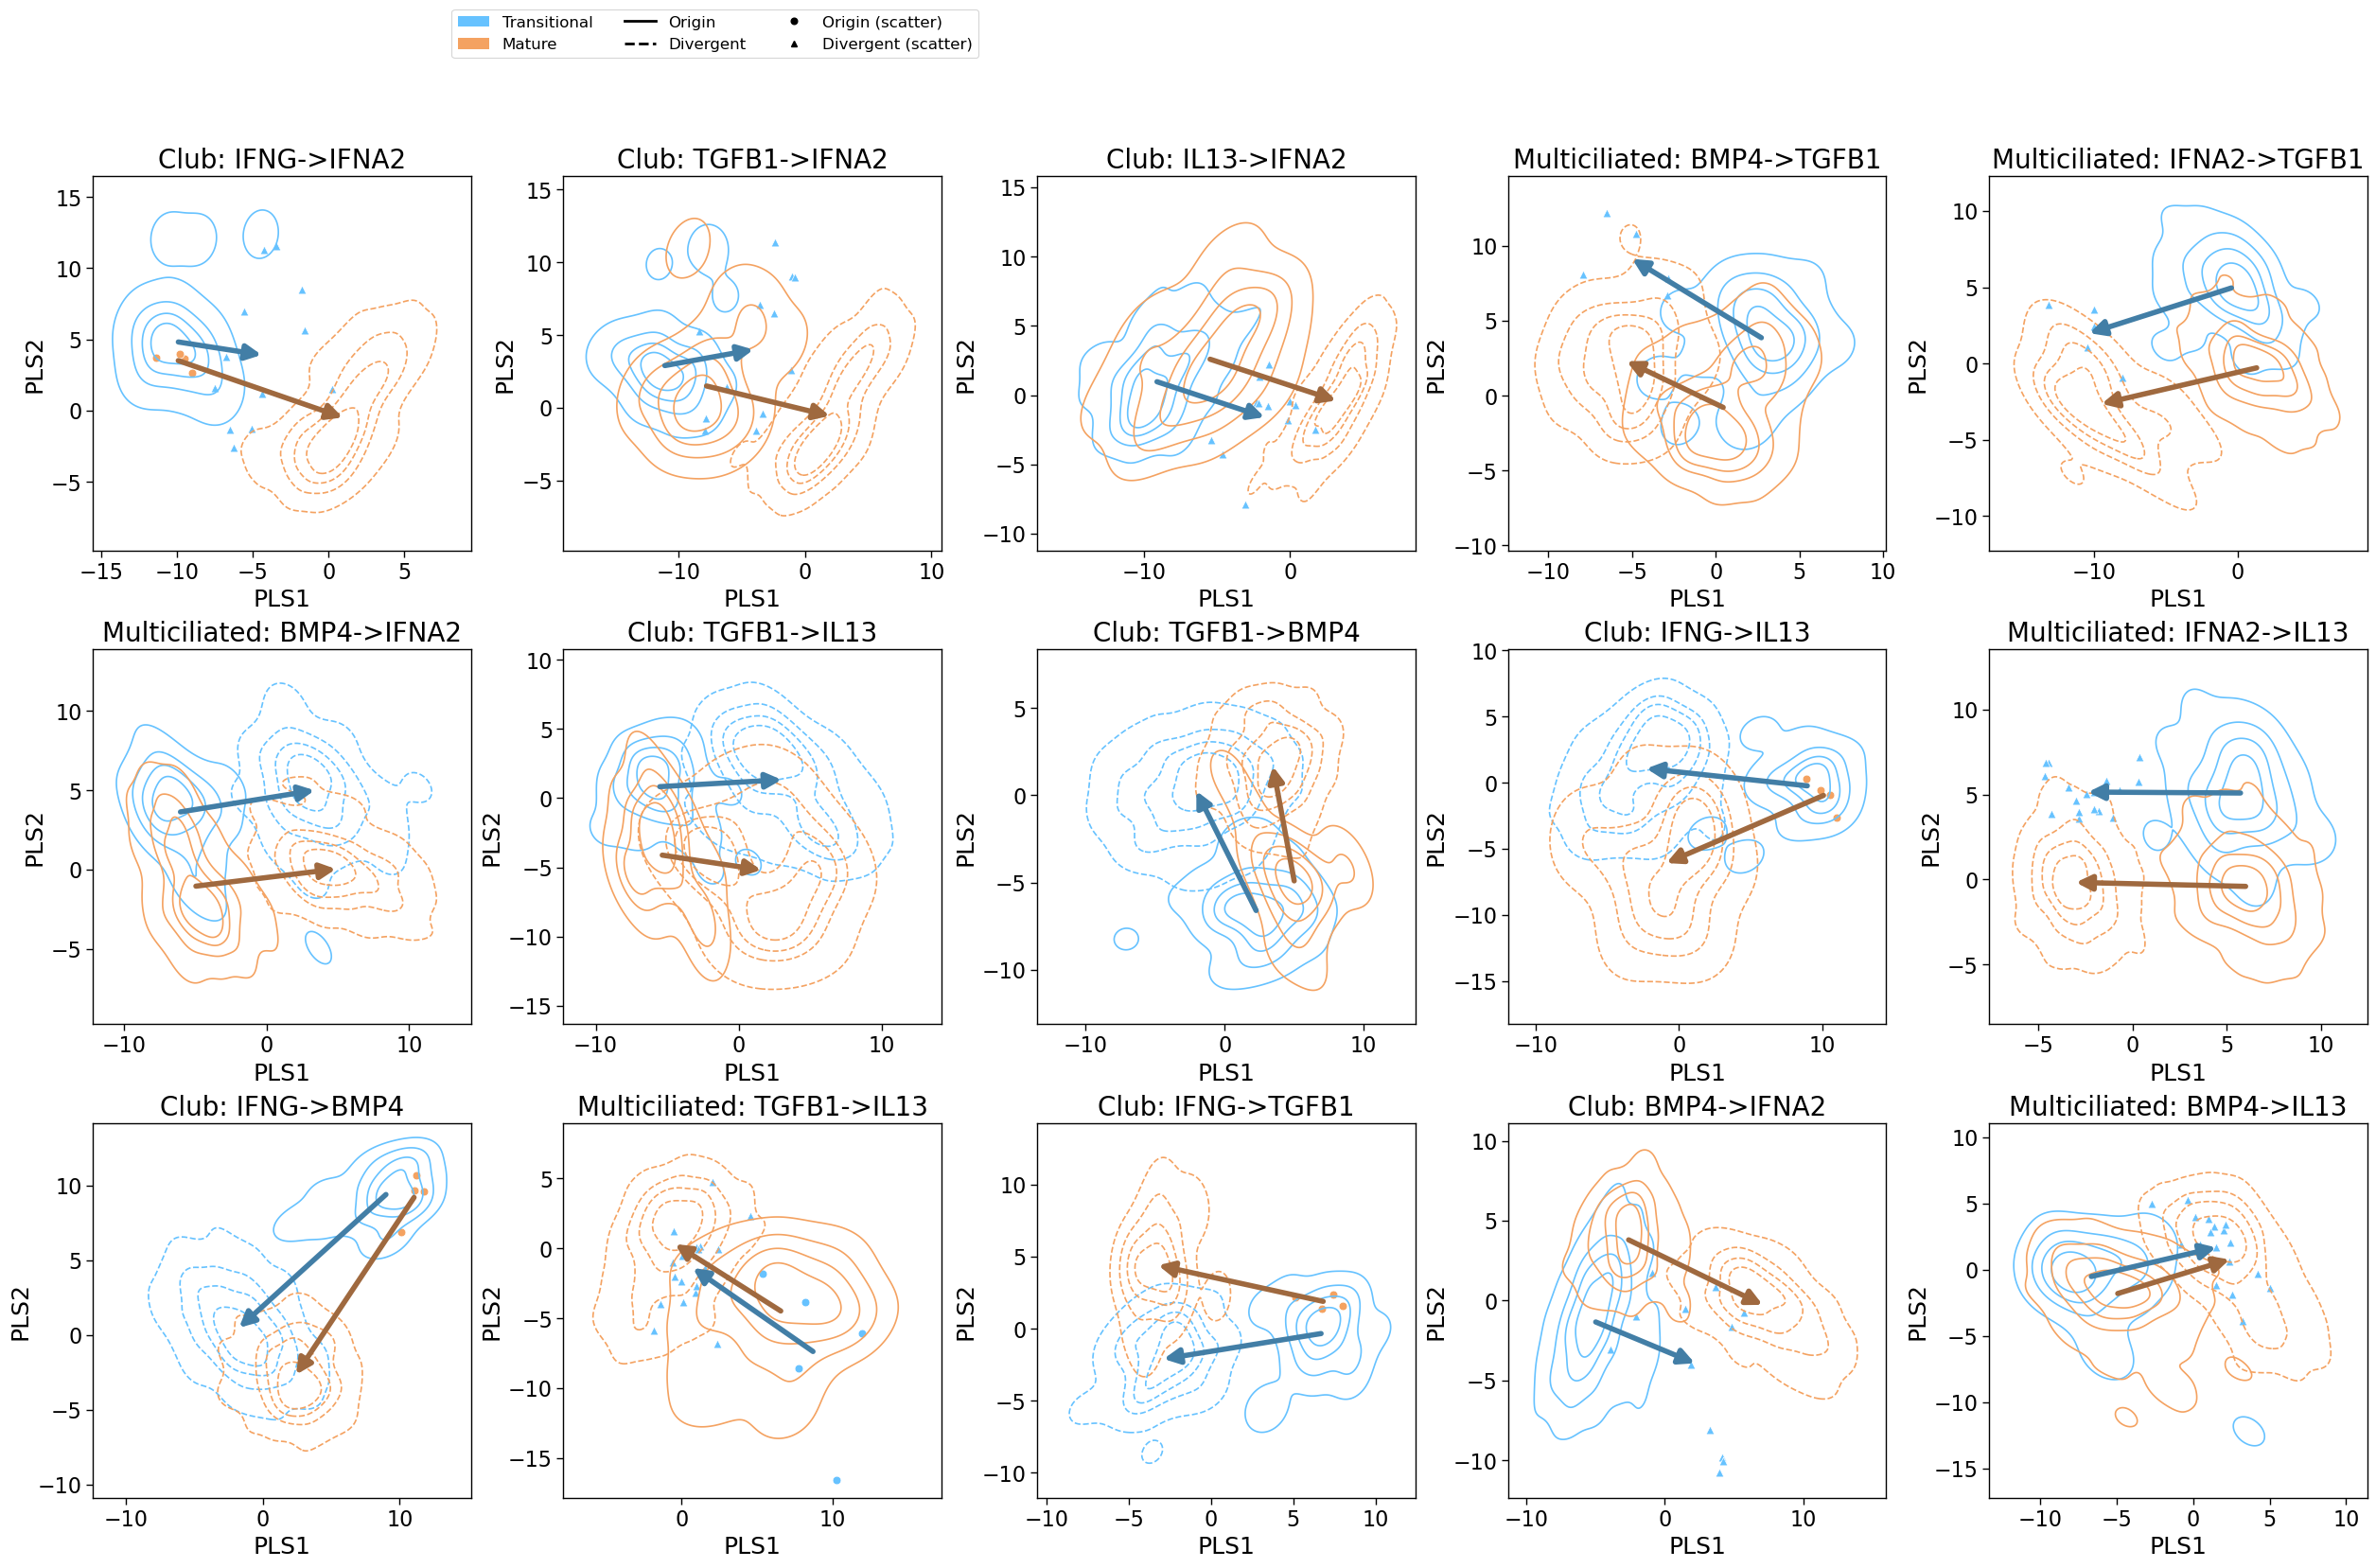

In [18]:
n_panels = distances_df.shape[0]
ncols = min(5, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (5*ncols, 5*nrows), constrained_layout = True)
ax = np.array(ax).reshape(-1)

for idx, row in distances_df.iterrows():
    cond = row['condition']
    origin_pert = row['origin_perturbation']
    
    viz_df = pls_dataframes[cond].copy().drop(columns = [cat_col])

    plot_panel(viz_df, ax[idx], cond_ = cond, n_scatter = 25, origin_pert = origin_pert)
    
    if idx == 0:
        legend = ax[idx].get_legend()
        handles = legend.legend_handles
        labels = [t.get_text() for t in legend.texts]
    
    ax[idx].legend_.remove()

# add figure-level legend
fig.legend(
    handles = handles,
    labels = labels,
    loc = 'upper center',
    ncol = 3,
    title = '', 
    bbox_to_anchor = (0.3, 1.1)
)

for j in range(idx + 1, len(ax)):
    ax[j].axis('off')
    

In [16]:
distances_df[['condition'] + pca_cols]

,condition,euclidean_distance_ratio,mahanalobis_distance_ratio,subtype_cosine_distance,transition_projection_error,mature_projection_error
0,Club^IFNG->IFNA2,2.789874,2.225772,0.288133,0.809532,0.288314
1,Club^TGFB1->IFNA2,1.532297,2.677249,0.186851,0.690787,0.356040
2,Club^IL13->IFNA2,1.427768,2.087888,0.061057,0.722715,0.507311
3,Multiciliated^BMP4->TGFB1,1.292092,1.295556,0.009657,0.141314,0.010969
4,Multiciliated^IFNA2->TGFB1,1.050907,1.062348,0.030830,0.228781,0.028882
5,Multiciliated^BMP4->IFNA2,1.257333,1.153464,0.035607,0.235430,0.030693
6,Club^TGFB1->IL13,1.202123,1.300689,0.020984,0.116954,0.294440
7,Club^TGFB1->BMP4,1.171402,1.060848,0.089497,0.118611,0.304640
8,Club^IFNG->IL13,2.395385,1.272825,0.139123,0.081066,0.438409
9,Multiciliated^IFNA2->IL13,1.086264,1.807836,0.030523,0.277067,0.085639


~~Despite the "divergent" filter, these still seem not strongly divergent. A large contributor to this is likely the few cells in certain conditions. However, in other instances, let's check if it's not simply using the first two PLS components rather than all by visualizing in UMAP space:~~

In [18]:
# n_panels = distances_df.shape[0]
# ncols = min(5, n_panels)
# nrows = int(np.ceil(n_panels / ncols))

# fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (5*ncols, 5*nrows), constrained_layout = True)
# ax = np.array(ax).reshape(-1)

# for idx, row in distances_df.iterrows():
#     cond = row['condition']
#     origin_pert = row['origin_perturbation']
    
#     viz_df = umap_dataframes[cond].copy().drop(columns = [cat_col])

#     plot_panel(viz_df, ax[idx], cond_ = cond, n_scatter = 25, origin_pert = origin_pert)
    
#     if idx == 0:
#         legend = ax[idx].get_legend()
#         handles = legend.legend_handles
#         labels = [t.get_text() for t in legend.texts]
    
#     ax[idx].legend_.remove()

# # add figure-level legend
# fig.legend(
#     handles = handles,
#     labels = labels,
#     loc = 'upper center',
#     ncol = 2,
#     title = '', 
#     bbox_to_anchor = (0.3, 1.1)
# )

# for j in range(idx + 1, len(ax)):
#     ax[j].axis('off')
    

In [19]:
joblib.dump(pls_models, os.path.join(data_path, 'processed', 'cellsubtype_pls_models_pert.joblib'))
distances_df.to_csv(os.path.join(data_path, 'interim', 'cellsubtype_pls_euclidean_distances_pert.csv'))